In [1]:
!pip install osmnx geopandas shapely pyproj rtree


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 4.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import osmnx as ox
import geopandas as gpd
from shapely.geometry import Point
from tqdm import tqdm


In [3]:
from google.colab import files
uploaded = files.upload()


Saving Pollution_Weather_datset.csv to Pollution_Weather_datset.csv


In [4]:
import pandas as pd

df = pd.read_csv("Pollution_Weather_datset.csv")
df.head()


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Temperature (C),Humidity (%),Wind Speed (m/s),Wind Direction (deg),Latitude,Longitude,Timestamp,Source_API
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate,5.4,90.0,0.92,41.0,44.7444,44.2031,1.764709e+09,OpenWeatherMap
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,27.7,56.0,4.26,129.0,-5.2900,-44.4900,1.764709e+09,OpenWeatherMap
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate,18.0,71.0,2.75,123.0,37.1572,15.1802,1.764709e+09,OpenWeatherMap
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good,1.6,98.0,2.60,122.0,53.0191,20.8803,1.764709e+09,OpenWeatherMap
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good,25.2,85.0,1.06,49.0,-17.6333,-149.6000,1.764709e+09,OpenWeatherMap


In [7]:
# Load dataset
df = pd.read_csv("Pollution_Weather_datset.csv")


# Ensure required columns exist
required_cols = {"City", "Latitude", "Longitude"}
if not required_cols.issubset(df.columns):
    raise ValueError("CSV must contain city, latitude, longitude columns")

# Create GeoDataFrame
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.Longitude, df.Latitude),
    crs="EPSG:4326"
)


In [20]:
# Ensure key columns exist
required = ["Country", "City", "AQI Category"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")


In [21]:
TARGET_SIZE = 10000

country_counts = df["Country"].value_counts()
country_weights = country_counts / country_counts.sum()

country_targets = (country_weights * TARGET_SIZE).round().astype(int)

# Adjust rounding to get exact 10,000
difference = TARGET_SIZE - country_targets.sum()
if difference != 0:
    country_targets.iloc[0] += difference


In [22]:
sampled_dfs = []

for country, target in country_targets.items():
    country_df = df[df["Country"] == country]

    if len(country_df) <= target:
        sampled_dfs.append(country_df)
        continue

    # Stratify by City & AQI Category
    stratified = (
        country_df
        .groupby(["City", "AQI Category"], group_keys=False)
        .apply(lambda x: x.sample(
            n=max(1, int(target * len(x) / len(country_df))),
            random_state=42
        ))
    )

    sampled_dfs.append(stratified)


/tmp/ipython-input-2004654116.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipython-input-2004654116.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(
/tmp/ipython-input-2004654116.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping 

In [23]:
final_sample = pd.concat(sampled_dfs, ignore_index=True)

# If slightly more than 10k, trim safely
if len(final_sample) > TARGET_SIZE:
    final_sample = final_sample.sample(TARGET_SIZE, random_state=42)

print("Final sample size:", len(final_sample))


Final sample size: 10000


In [24]:
final_sample.to_csv("Pollution_Stratified_10000.csv", index=False)
print("✅ Saved: Pollution_Stratified_10000.csv")


✅ Saved: Pollution_Stratified_10000.csv


In [52]:
import pandas as pd

df = pd.read_csv("Pollution_Stratified_10000.csv")
print("Rows:", len(df))
df.head()


Rows: 10000


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Temperature (C),Humidity (%),Wind Speed (m/s),Wind Direction (deg),Latitude,Longitude,Timestamp,Source_API
0,Germany,Velbert,28,Good,0,Good,26,Good,2,Good,28,Good,6.17,75.0,4.30,170.0,51.3333,7.0500,1.764690e+09,OpenWeatherMap
1,Germany,Blomberg,45,Good,1,Good,44,Good,0,Good,45,Good,5.70,92.0,4.80,183.0,51.9433,9.0907,1.764709e+09,OpenWeatherMap
2,India,Richha,177,Unhealthy,4,Good,177,Unhealthy,1,Good,156,Unhealthy,17.30,70.0,1.80,270.0,28.7000,79.5167,1.764709e+09,OpenWeatherMap
3,Germany,Bad Nenndorf,37,Good,0,Good,33,Good,1,Good,37,Good,6.53,79.0,2.57,150.0,52.3333,9.3667,1.764690e+09,OpenWeatherMap
4,Colombia,Zarzal,73,Moderate,2,Good,3,Good,5,Good,73,Moderate,23.53,78.0,0.62,24.0,4.3946,-76.0715,1.764690e+09,OpenWeatherMap


In [56]:
distance_cols = [
    "dist_to_road_m",
    "dist_to_industry_m",
    "dist_to_dump_m",
    "dist_to_farmland_m"
]

for col in distance_cols:
    if col not in df.columns:
        df[col] = None


In [64]:
no2_75 = df["NO2 AQI Value"].quantile(0.75)
co_75  = df["CO AQI Value"].quantile(0.75)
co_85  = df["CO AQI Value"].quantile(0.85)
o3_75  = df["Ozone AQI Value"].quantile(0.75)

pm25_60 = df["PM2.5 AQI Value"].quantile(0.60)
pm25_85 = df["PM2.5 AQI Value"].quantile(0.85)

no2_50 = df["NO2 AQI Value"].quantile(0.50)


In [65]:
def label_pollution_source_final(row):
    pm25 = row["PM2.5 AQI Value"]
    no2  = row["NO2 AQI Value"]
    co   = row["CO AQI Value"]
    o3   = row["Ozone AQI Value"]

    # 1️⃣ Vehicular (relative traffic hotspots)
    if (no2 >= no2_75 and co >= co_75):
        return "Vehicular", 0.75

    # 2️⃣ Industrial (combustion + ozone)
    if (co >= co_85 and o3 >= o3_75):
        return "Industrial", 0.75

    # 3️⃣ Burning (extreme particulate)
    if pm25 >= pm25_85:
        return "Burning", 0.8

    # 4️⃣ Agricultural (dust + moderate PM)
    if (pm25 >= pm25_60 and pm25 < pm25_85 and no2 <= no2_50):
        return "Agricultural", 0.7

    # 5️⃣ Natural (background)
    return "Natural", 0.5


In [66]:
df[["pollution_source", "source_confidence"]] = df.apply(
    lambda r: pd.Series(label_pollution_source_final(r)),
    axis=1
)


In [67]:
df["pollution_source"].value_counts()


,count
pollution_source,
Natural,5301
Vehicular,2493
Agricultural,1033
Industrial,588
Burning,585


In [68]:
features = [
    "CO AQI Value",
    "NO2 AQI Value",
    "PM2.5 AQI Value",
    "Ozone AQI Value",
    "Temperature (C)",
    "Humidity (%)",
    "Wind Speed (m/s)"
]

X = df[features]
y = df["pollution_source"]


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [70]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Classes:", le.classes_)


Classes: ['Agricultural' 'Burning' 'Industrial' 'Natural' 'Vehicular']


In [71]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train_enc)


RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [72]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test_enc, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))


Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

Agricultural       1.00      1.00      1.00       207
     Burning       1.00      1.00      1.00       117
  Industrial       1.00      1.00      1.00       117
     Natural       1.00      1.00      1.00      1060
   Vehicular       1.00      1.00      1.00       499

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



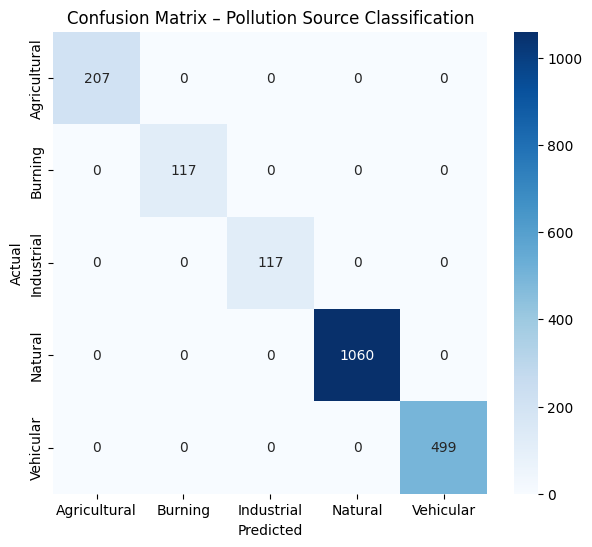

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_enc, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Pollution Source Classification")
plt.show()


In [74]:
importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

importance_df


,Feature,Importance
2,PM2.5 AQI Value,0.334764
1,NO2 AQI Value,0.282399
0,CO AQI Value,0.148733
3,Ozone AQI Value,0.138660
4,Temperature (C),0.043282
5,Humidity (%),0.038879
6,Wind Speed (m/s),0.013284


In [75]:
import joblib

joblib.dump(rf, "pollution_source_model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("✅ Model & encoder saved")


✅ Model & encoder saved


In [76]:
!pip install folium


In [77]:
import folium
from folium.plugins import HeatMap


In [78]:
map_df = df.dropna(subset=["Latitude", "Longitude"])


In [79]:
heat_map = folium.Map(
    location=[map_df["Latitude"].mean(), map_df["Longitude"].mean()],
    zoom_start=2,
    tiles="cartodbpositron"
)

heat_data = map_df[["Latitude", "Longitude", "PM2.5 AQI Value"]].values.tolist()

HeatMap(
    heat_data,
    radius=10,
    blur=15
).add_to(heat_map)

heat_map


In [80]:
source_colors = {
    "Vehicular": "red",
    "Industrial": "blue",
    "Agricultural": "green",
    "Burning": "orange",
    "Natural": "purple"
}

source_map = folium.Map(
    location=[map_df["Latitude"].mean(), map_df["Longitude"].mean()],
    zoom_start=2,
    tiles="cartodbpositron"
)

for _, row in map_df.sample(1500, random_state=42).iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=4,
        color=source_colors[row["pollution_source"]],
        fill=True,
        fill_opacity=0.7,
        popup=(
            f"City: {row['City']}<br>"
            f"Source: {row['pollution_source']}<br>"
            f"Confidence: {row['source_confidence']}"
        )
    ).add_to(source_map)

source_map


In [81]:
high_risk = map_df[
    (map_df["AQI Category"].isin(["Poor", "Very Poor", "Severe"])) |
    (map_df["PM2.5 AQI Value"] > pm25_85)
]

risk_map = folium.Map(
    location=[map_df["Latitude"].mean(), map_df["Longitude"].mean()],
    zoom_start=2,
    tiles="cartodbpositron"
)

for _, row in high_risk.sample(min(800, len(high_risk)), random_state=42).iterrows():
    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=6,
        color="black",
        fill_color="red",
        fill_opacity=0.8,
        popup=f"🚨 {row['pollution_source']} – {row['AQI Category']}"
    ).add_to(risk_map)

risk_map


In [83]:
# Select final columns (keep everything + predictions)
final_df = df.copy()

# Optional: reorder important columns for clarity
important_cols = [
    "Country",
    "City",
    "Latitude",
    "Longitude",
    "AQI Value",
    "AQI Category",
    "CO AQI Value",
    "NO2 AQI Value",
    "Ozone AQI Value",
    "PM2.5 AQI Value",
    "Temperature (C)",
    "Humidity (%)",
    "Wind Speed (m/s)",
    "pollution_source",
    "source_confidence",
    "Timestamp",
    "Source_API"
]

# Keep only columns that actually exist
important_cols = [c for c in important_cols if c in final_df.columns]

final_df = final_df[important_cols]

# Save final CSV
final_csv_path = "EnviroScan_Final_Pollution_Source_Predictions.csv"
final_df.to_csv(final_csv_path, index=False)

final_csv_path


'EnviroScan_Final_Pollution_Source_Predictions.csv'

In [84]:
from google.colab import files

final_csv_path = "EnviroScan_Final_Pollution_Source_Predictions.csv"

# Save (in case not already saved)
final_df.to_csv(final_csv_path, index=False)

# Trigger download
files.download(final_csv_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>